# CytoSignal — breast_atera Results Notebook

Journal club companion to Liu et al., *Nature Genetics* 2026 — CytoSignal, applied to the `breast_atera` spatial dataset (grafiti sweep run `breast_atera_nosplit_nobatch__large_lr1e-4_m12_eps0.01_w1000`), clustered by the external breast cell-type labels.

**This notebook only loads a precomputed `.rds` — it does not re-run the permutation test.** Run `01_cytosignal_breast_atera.R` (via `02_pilot.sbatch` / `02_full.sbatch` in [`pipeline/`](pipeline/)) first.

Kernel: **R (cytosignal-r)** (IRkernel). See [`pipeline/README.md`](pipeline/README.md) for one-time environment setup.

## 1. Setup & load results

In [1]:
suppressPackageStartupMessages({
  library(cytosignal)
  library(ggplot2)
  library(knitr)
  library(dplyr)
})
options(width = 120)

In [ ]:
# Path relative to wherever you run this notebook, matching the pipeline's
# ./cytosignal_output_full/ (or _pilot/) OUTPUT_DIR -- adjust if yours differs.
RDS_PATH <- "cytosignal_output_full/cytosignal_breast_atera_checkpoint.rds"
cs <- readRDS(RDS_PATH)
cs

# The checkpoint .rds (and any run where rankIntrSpatialVar()/SPARK failed) won't
# have "result.spx" -- fall back to "result.hq" everywhere below so the rest of
# this notebook works either way. Interactions/plots are unaffected, only the
# spatial-variability sort order is missing on the fallback path.
SIGNIF_USE <- if ("result.spx" %in% names(cs@lrscore[["diffusion-Raw_smooth"]]@res.list)) {
  "result.spx"
} else {
  "result.hq"
}
cat("Using signif.use =", SIGNIF_USE, "\n")

### What this object summary means

- **`Number of cells: 170029`** — of ~170,034 loaded, 5 were dropped by `removeLowQuality()`'s `COUNTS_THRESH=10` floor.
- **`Number of genes: 3990`** — 10 of 4000 genes were dropped (low-quality, or not mappable to a Uniprot ID in the LR database).
- **`Number of clusters: 10`** — the `grafiti_celltype` → cell-type-name mapping (Cancer1_1, Fibroblast, CAF-Fibroblast, etc.) came through correctly.

**Nearest neighbor imputation: `diffusion`, `contact`, `Raw`** — the three spatial neighborhoods CytoSignal builds:

| Neighborhood | Definition | Used for |
|---|---|---|
| `diffusion` | Gaussian epsilon-ball (200µm radius) | diffusible ligands (cytokines, chemokines, growth factors) |
| `contact` | Delaunay triangulation | contact-dependent ligands (juxtacrine signaling, touching cells only) |
| `Raw` | no smoothing — each cell's own expression | baseline receptor expression |

**LR scores** — all six ligand-imputation × receptor-smoothing combinations were computed (`diffusion-Raw`, `diffusion-Raw_smooth`, `contact-Raw`, `contact-Raw_smooth`, `Raw-Raw`, `Raw-Raw_smooth`). This notebook uses **`diffusion-Raw_smooth`** and **`contact-Raw_smooth`** specifically — the two variants the package vignette recommends for diffusion-dependent and contact-dependent interactions, respectively, on single-cell-resolution data like ours (`Raw-Raw` is intended for multi-cell Visium-style spots, not applicable here).

**Parameters:**
- `r.diffuse.scale: 200` — the fixed 200µm epsilon-ball radius (package default)
- `sigma.scale: 53.81` — the Gaussian kernel width, auto-derived from this dataset's actual cell density and `SCALE_FACTOR = 1.0`. A plausible value relative to the 200µm search radius — a useful sanity check that the scale-factor assumption (coordinates already in µm) was reasonable.

## 2. Dataset overview

In [3]:
cluster_tab <- as.data.frame(table(cell_type = cs@clusters))
kable(cluster_tab)



|cell_type                 |  Freq|
|:-------------------------|-----:|
|CAF-Fibroblast            |  5548|
|Cancer1_1                 | 28250|
|Cancer1_2                 | 16316|
|Cancer1-Cancer3-Cycling_1 | 27011|
|Cancer1-Cancer3-Cycling_2 |  7955|
|Cancer2                   | 14555|
|Endothelial-Perivascular  | 18575|
|Fibroblast                |  3033|
|Fibroblast-Cancer3        | 15069|
|Fibroblast-Macrophage     | 33717|

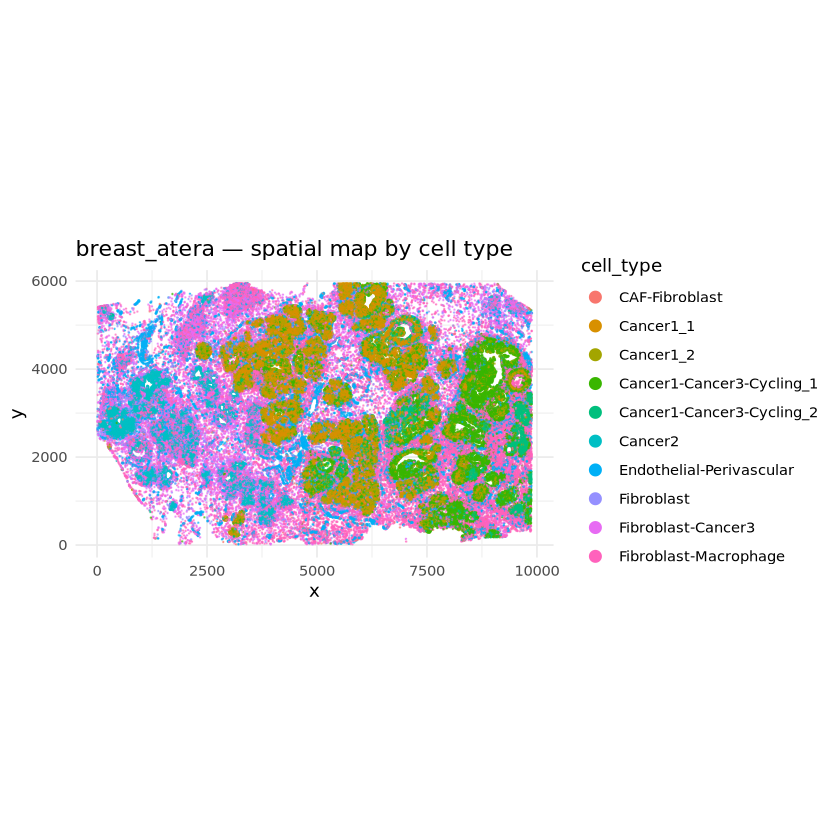

In [9]:
loc_df <- as.data.frame(cs@cells.loc)
loc_df$cell_type <- cs@clusters

ggplot(loc_df, aes(x = x, y = y, color = cell_type)) +
  geom_point(size = 0.1, alpha = 0.5) +
  coord_fixed() +
  theme_minimal() +
  guides(color = guide_legend(override.aes = list(size = 3, alpha = 1))) +
  labs(title = "breast_atera — spatial map by cell type")

In [10]:
cat(sprintf("cells: %d\ngenes: %d\nx range: [%.1f, %.1f]\ny range: [%.1f, %.1f]\n",
            ncol(cs@counts), nrow(cs@counts),
            min(loc_df$x), max(loc_df$x), min(loc_df$y), max(loc_df$y)))

cells: 170029
genes: 432
x range: [5.2, 9884.5]
y range: [12.7, 5952.6]


## 3. Significant interactions — summary

In [13]:
# ===== How many interactions were tested vs. significant, per score type =====
intr_counts <- function(cs, slot) {
  lr <- cs@lrscore[[slot]]
  db_total   <- nlevels(cs@intr.valid[[lr@intr.slot]][["combined"]])  # fixed
  tested     <- ncol(lr@score)
  significant<- length(lr@res.list[["result"]])
  hq         <- length(lr@res.list[["result.hq"]])
  spx        <- if ("result.spx" %in% names(lr@res.list)) length(lr@res.list[["result.spx"]]) else NA
  data.frame(slot = slot, in_database = db_total, tested = tested,
             significant = significant, high_quality = hq, spatially_variable = spx)
}

count_summary <- rbind(
  intr_counts(cs, "diffusion-Raw_smooth"),
  intr_counts(cs, "contact-Raw_smooth")
)
kable(count_summary, caption = "Interactions tested vs. significant, by score type")



Table: Interactions tested vs. significant, by score type

|slot                 | in_database| tested| significant| high_quality|spatially_variable |
|:--------------------|-----------:|------:|-----------:|------------:|:------------------|
|diffusion-Raw_smooth |         754|     87|          87|           80|NA                 |
|contact-Raw_smooth   |         109|     36|          36|           35|NA                 |

### Notes on table/results above

Can all be significant? Yes, and here's why that's not as strong a claim as it sounds. "Significant" (result) only requires at least one cell out of 170,029 to pass p < 0.05 after the spatial permutation test — literally res.list <- res.list[lengths(res.list) != 0] in inferSignif(), i.e. "did this interaction show up as significant anywhere in the tissue." With that many cells tested, essentially any interaction with real expression will clear that bar somewhere by chance or genuine signal — it's a low threshold, which is exactly why 87/87 and 36/36 pass it.

What is high_quality? The next filter down (result.hq), applying two additional thresholds beyond raw significance: reads.thresh (minimum total reads backing the interaction) and sig.thresh (minimum number of significant cells, not just one). This is the threshold that actually does discriminating work — it's why you see 80/87 and 35/36 rather than 87/87 and 36/36. Treat result.hq, not result, as your real "significant interactions" list.

In [36]:
library(Matrix)
# ===== Cell type x cell type signaling matrix, top interactions =====
# countEdges() aggregates sender->receiver edges (from the spatial neighbor
# graph) weighted by significant interactions in the receiver, normalized by
# total possible edges between each cluster pair. Same machinery plotCircosNIntr
# uses internally -- no circlize dependency here, just the underlying matrix.
top_diff <- showIntr(cs, slot.use = "diffusion-Raw_smooth", signif.use = SIGNIF_USE, return.name = TRUE)
top_cont <- showIntr(cs, slot.use = "contact-Raw_smooth", signif.use = SIGNIF_USE, return.name = TRUE)

In [37]:
# Reimplementation of cytosignal:::countEdges (avoids a real bug in the
# installed package: unqualified %||% used without importing it from rlang,
# only available as a base R operator from R>=4.4; we're on R 4.3.3).
my_countEdges <- function(object, lrscore.use, intr.use = NULL) {
  scorename <- lrscore.use
  res.list <- object@lrscore[[scorename]]@res.list[["result.hq"]]
  lig.slot <- object@lrscore[[scorename]]@lig.slot
  intr.list <- names(res.list)
  nn.graph <- object@imputation[[lig.slot]]@nn.graph
  barcodes <- colnames(object@raw.counts)

  intrs <- if (is.null(intr.use)) intr.list else intr.use
  intrs <- intrs[intrs %in% intr.list]
  if (length(intrs) == 0) stop("No interactions in `intr.use` found for ", scorename)

  # FIX: the upstream cytosignal::countEdges() computes `intrs` but never
  # applies it below -- a real dead-filter bug that makes every query return
  # the identical whole-slot aggregate. Restrict res.list here instead.
  res.list <- res.list[intrs]

  all_counts <- lapply(seq_along(res.list), function(i) {
    data.frame(receiver = res.list[[i]], intr = names(res.list)[i], count = 1)
  })
  all_counts <- Reduce(rbind, all_counts)
  all_counts$receiver <- match(all_counts$receiver, barcodes)
  all_counts$intr <- match(all_counts$intr, intrs)
  receiver.intr.mtx <- Matrix::sparseMatrix(
    i = all_counts$receiver, j = all_counts$intr, x = all_counts$count,
    dims = c(length(barcodes), length(intrs)),
    dimnames = list(barcodes, intrs)
  )

  nIntrPerReceiver <- Matrix::rowSums(receiver.intr.mtx)
  cluster.cell.mtx <- Matrix::fac2sparse(object@clusters)
  sender.receiver.mtx <- nn.graph
  sender.receiver.mtx@x <- rep(1, length(sender.receiver.mtx@x))
  cluster.receiver.mtx <- cluster.cell.mtx %*% sender.receiver.mtx
  cluster.cluster.NIntr <- sweep(cluster.receiver.mtx, 2, nIntrPerReceiver, "*") %*% Matrix::t(cluster.cell.mtx)
  cluster.cluster.totalIntr <- Matrix::colSums(sender.receiver.mtx %*% Matrix::t(cluster.cell.mtx)) * length(intrs)
  sweep(cluster.cluster.NIntr, 2, cluster.cluster.totalIntr, "/")
}

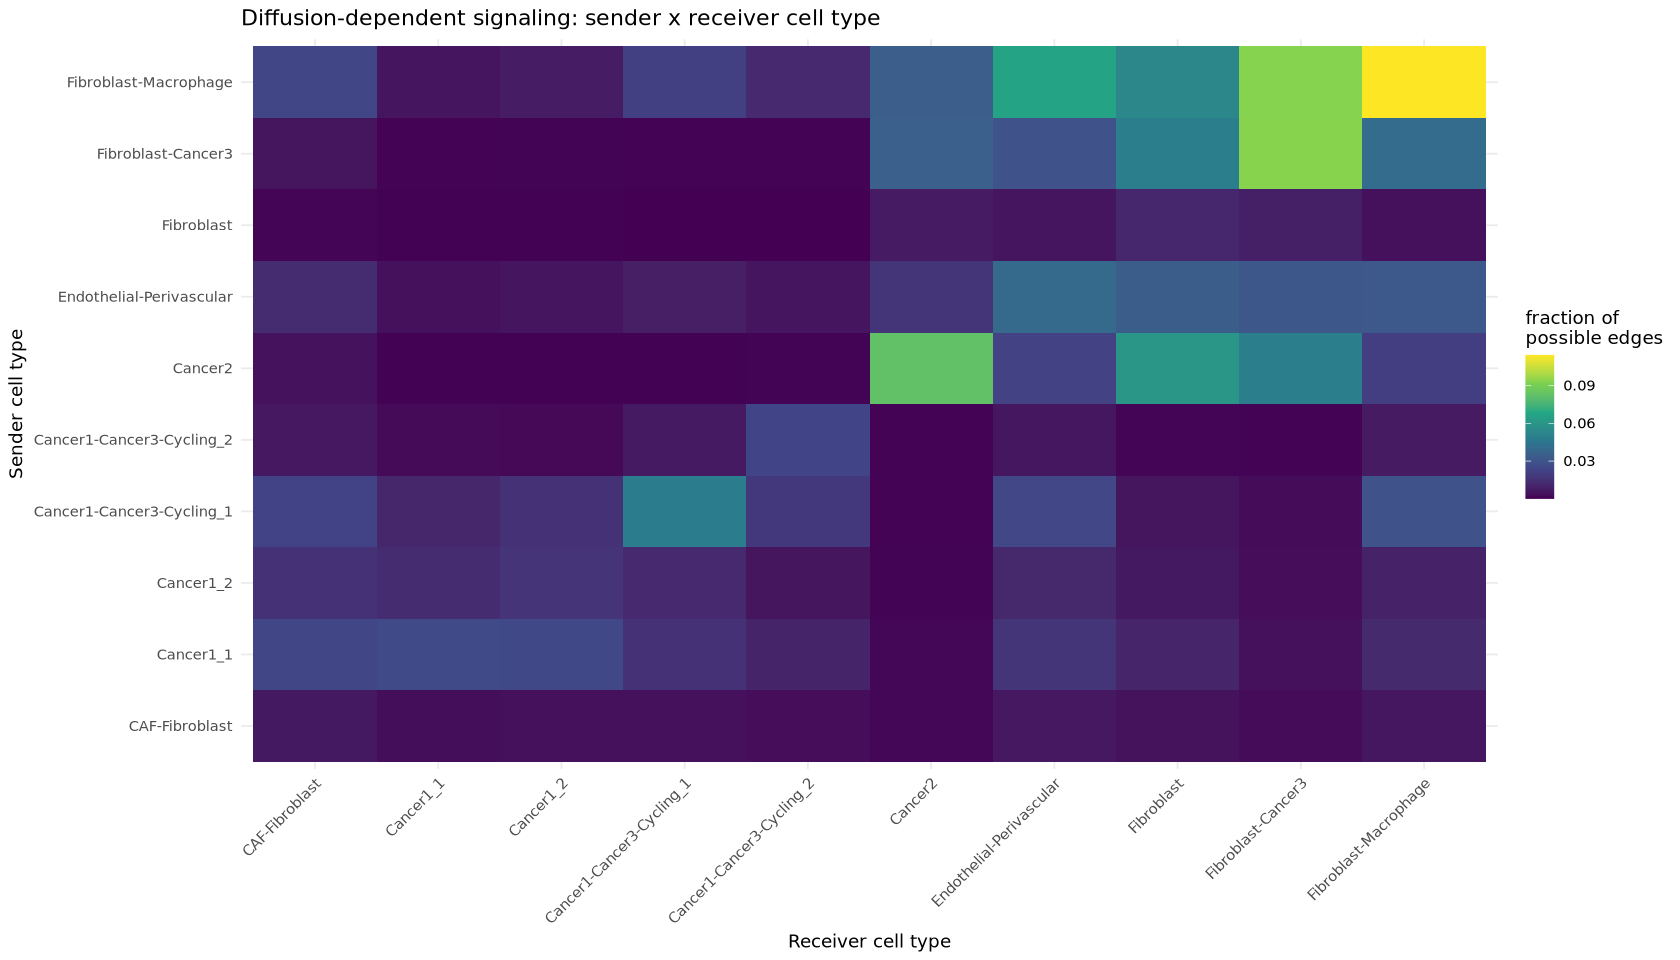

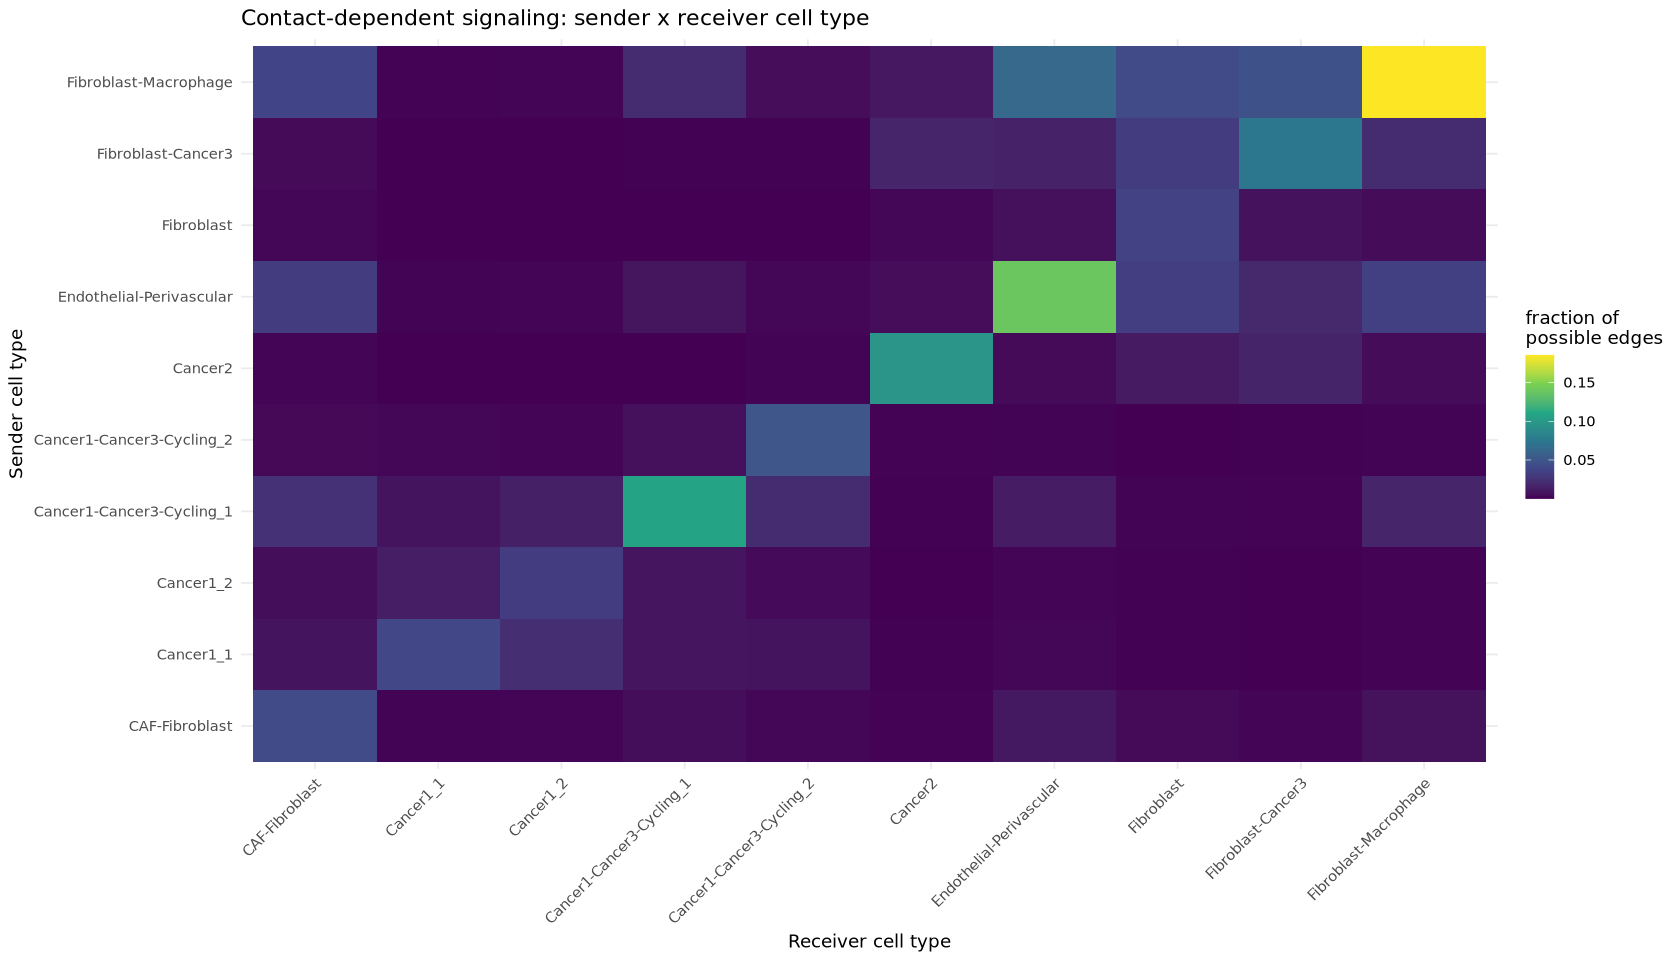

In [38]:
plot_cluster_heatmap <- function(mtx, title) {
  df <- as.data.frame(as.matrix(mtx))
  df$sender <- rownames(df)
  df <- tidyr::pivot_longer(df, -sender, names_to = "receiver", values_to = "frac")
  ggplot(df, aes(x = receiver, y = sender, fill = frac)) +
    geom_tile() +
    scale_fill_viridis_c(name = "fraction of\npossible edges") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = title, x = "Receiver cell type", y = "Sender cell type")
}

plot_cluster_heatmap(edge_mtx_diff, "Diffusion-dependent signaling: sender x receiver cell type")
plot_cluster_heatmap(edge_mtx_cont, "Contact-dependent signaling: sender x receiver cell type")

In [19]:
top_diff <- showIntr(cs, slot.use = "diffusion-Raw_smooth", signif.use = SIGNIF_USE, return.name = TRUE)
top_cont <- showIntr(cs, slot.use = "contact-Raw_smooth", signif.use = SIGNIF_USE, return.name = TRUE)

kable(data.frame(id = names(top_diff), name = top_diff)[seq_len(min(10, length(top_diff))), ],
      caption = "Top diffusion-dependent interactions")



Table: Top diffusion-dependent interactions

|                |id              |name                    |
|:---------------|:---------------|:-----------------------|
|CPI-SC0D5CFA431 |CPI-SC0D5CFA431 |TGFB3-TGFbeta receptor1 |
|CPI-SS0F0D7F25C |CPI-SS0F0D7F25C |BTC-ERBB4               |
|CPI-SC03DD946B2 |CPI-SC03DD946B2 |TGFB2-TGFbeta receptor1 |
|CPI-SS02AB0C3E0 |CPI-SS02AB0C3E0 |OSTP-CD44               |
|CPI-SS03A4F7DC8 |CPI-SS03A4F7DC8 |GAS6-UFO                |
|CPI-SS0FFB9E01B |CPI-SS0FFB9E01B |FGF4-FGFR1              |
|CPI-CS0BAF97962 |CPI-CS0BAF97962 |PDGFD-PDGFR complex     |
|CPI-CS073D36B1D |CPI-CS073D36B1D |PLGF-FLT1 complex       |
|CPI-SS0755A26DD |CPI-SS0755A26DD |FGF1-FGFR1              |
|CPI-SS0B70EB09E |CPI-SS0B70EB09E |PDGFA-PGFRA             |

In [20]:
kable(data.frame(id = names(top_cont), name = top_cont)[seq_len(min(10, length(top_cont))), ],
      caption = "Top contact-dependent interactions")



Table: Top contact-dependent interactions

|                |id              |name               |
|:---------------|:---------------|:------------------|
|CPI-SS0B99F22A2 |CPI-SS0B99F22A2 |JAG1-NOTC3         |
|CPI-SS044C72D0D |CPI-SS044C72D0D |SEM4A-PLXD1        |
|CPI-SS06F83AE58 |CPI-SS06F83AE58 |LYAM2-CD44         |
|CPI-SS00D153A8A |CPI-SS00D153A8A |DLL4-NOTC4         |
|CPI-SS0FB5FE587 |CPI-SS0FB5FE587 |DLL1-NOTC4         |
|CPI-SS0B87FE6E0 |CPI-SS0B87FE6E0 |JAG1-NOTC1         |
|CPI-SS0822AEF5F |CPI-SS0822AEF5F |PTPRC-MRC1         |
|CPI-SS047232C64 |CPI-SS047232C64 |DLL1-NOTC3         |
|CPI-SC0B6D68FD5 |CPI-SC0B6D68FD5 |aMb2 complex-ICAM1 |
|CPI-SC0A9458008 |CPI-SC0A9458008 |aXb2 complex-ICAM1 |

In [39]:
# Dominant sender/receiver cell type for one interaction, from the same
# sender-cluster x receiver-cluster matrix my_countEdges() already computes.
top_celltypes_for_intr <- function(cs, slot, id) {
  mtx <- as.matrix(my_countEdges(cs, slot, id))
  idx <- which(mtx == max(mtx), arr.ind = TRUE)[1, ]
  data.frame(top_sender = rownames(mtx)[idx["row"]],
             top_receiver = colnames(mtx)[idx["col"]],
             frac = round(mtx[idx["row"], idx["col"]], 3))
}

n_show <- min(10, length(top_diff))
diff_celltypes <- do.call(rbind, lapply(names(top_diff)[seq_len(n_show)], function(id) {
  top_celltypes_for_intr(cs, "diffusion-Raw_smooth", id)
}))
diff_table <- cbind(data.frame(id = names(top_diff), name = top_diff)[seq_len(n_show), ], diff_celltypes)
kable(diff_table, caption = "Top diffusion-dependent interactions, with dominant sender/receiver cell type")



Table: Top diffusion-dependent interactions, with dominant sender/receiver cell type

|                |id              |name                    |top_sender            |top_receiver          |  frac|
|:---------------|:---------------|:-----------------------|:---------------------|:---------------------|-----:|
|CPI-SC0D5CFA431 |CPI-SC0D5CFA431 |TGFB3-TGFbeta receptor1 |Cancer2               |Cancer2               | 0.393|
|CPI-SS0F0D7F25C |CPI-SS0F0D7F25C |BTC-ERBB4               |Cancer2               |Cancer2               | 0.451|
|CPI-SC03DD946B2 |CPI-SC03DD946B2 |TGFB2-TGFbeta receptor1 |Fibroblast-Cancer3    |Fibroblast-Cancer3    | 0.274|
|CPI-SS02AB0C3E0 |CPI-SS02AB0C3E0 |OSTP-CD44               |Cancer2               |Cancer2               | 0.479|
|CPI-SS03A4F7DC8 |CPI-SS03A4F7DC8 |GAS6-UFO                |Fibroblast-Macrophage |Fibroblast-Cancer3    | 0.216|
|CPI-SS0FFB9E01B |CPI-SS0FFB9E01B |FGF4-FGFR1              |Cancer1_1             |Cancer1_2             | 0.263|


In [40]:
n_show_c <- min(10, length(top_cont))
cont_celltypes <- do.call(rbind, lapply(names(top_cont)[seq_len(n_show_c)], function(id) {
  top_celltypes_for_intr(cs, "contact-Raw_smooth", id)
}))
cont_table <- cbind(data.frame(id = names(top_cont), name = top_cont)[seq_len(n_show_c), ], cont_celltypes)
kable(cont_table, caption = "Top contact-dependent interactions, with dominant sender/receiver cell type")



Table: Top contact-dependent interactions, with dominant sender/receiver cell type

|                |id              |name               |top_sender                |top_receiver              |  frac|
|:---------------|:---------------|:------------------|:-------------------------|:-------------------------|-----:|
|CPI-SS0B99F22A2 |CPI-SS0B99F22A2 |JAG1-NOTC3         |Cancer2                   |Cancer2                   | 0.441|
|CPI-SS044C72D0D |CPI-SS044C72D0D |SEM4A-PLXD1        |Cancer1-Cancer3-Cycling_2 |Cancer1-Cancer3-Cycling_2 | 0.443|
|CPI-SS06F83AE58 |CPI-SS06F83AE58 |LYAM2-CD44         |Cancer2                   |Cancer2                   | 0.400|
|CPI-SS00D153A8A |CPI-SS00D153A8A |DLL4-NOTC4         |Endothelial-Perivascular  |Endothelial-Perivascular  | 0.257|
|CPI-SS0FB5FE587 |CPI-SS0FB5FE587 |DLL1-NOTC4         |Endothelial-Perivascular  |Endothelial-Perivascular  | 0.235|
|CPI-SS0B87FE6E0 |CPI-SS0B87FE6E0 |JAG1-NOTC1         |Cancer1_1                 |Cancer1_1    

**Diffusion vs. contact:** CytoSignal separately models diffusible ligands (epsilon-ball neighborhood, e.g. cytokines/chemokines/growth factors reaching cells at a distance) and contact-dependent ligands (Delaunay-triangulation neighbors only, i.e. juxtacrine signaling between touching cells). The two use different spatial null models for the permutation test, so an interaction being "significant" in one but not the other is itself informative about its signaling mode.

## do these interactions make sense for a breast cancer biopsy (Claude)??

Diffusion-dependent — genuinely recognizable pathways:

- `TGFB3/TGFB2 → TGFβ receptor1`, largely in Cancer2 and "Fibroblast-Cancer3" — canonical TGF-β autocrine signaling, a well-documented driver of EMT and immune evasion in breast tumors. Consistent with it being your #1 hit overall.
-- `OSTP(SPP1)-CD44 in Cancer2` (frac 0.479, your strongest single value) — osteopontin-CD44 is a well-established pro-metastatic/stemness axis in breast cancer.
- `PDGFD/PDGFA-PDGFR, FGF1/FGF4-FGFR1` concentrated in "Fibroblast-Cancer3" — classic CAF-activation signaling (PDGF/FGF paracrine loops are how tumors recruit and activate cancer-associated fibroblasts). Note this cluster's own name suggests it's a mixed/ambiguous fibroblast-tumor-boundary population in grafiti's own typing — so "autocrine" here may actually be capturing real fibroblast↔tumor crosstalk that just didn't cleanly separate into two clusters.
- `GAS6-UFO (GAS6-AXL), Fibroblast-Macrophage → Fibroblast-Cancer3`` — the one clearly heterotypic (different sender/receiver) hit in this list, and arguably the most interesting: GAS6-AXL is a well-studied macrophage-driven immunosuppression/EMT axis in the tumor microenvironment. This is worth highlighting specifically in the demo since it's cross-cell-type, not just co-clustered self-signal.

Contact-dependent — even stronger positive controls:

- `DLL4-NOTCH4 and DLL1-NOTCH4`, both autocrine in Endothelial-Perivascular — this is close to a textbook positive control. DLL4/Notch signaling in endothelial tip/stalk cells is the canonical angiogenesis-patterning pathway. Seeing it land cleanly in the endothelial cluster, unprompted, is a strong sign the pipeline is capturing real biology, not artifacts.
- `aMβ2/aXβ2 integrin complexes-ICAM1, PTPRC(CD45)-MRC1(CD206)`, all in Fibroblast-Macrophage — classic leukocyte adhesion/myeloid biology (Mac-1/CR3, CR4 are canonical macrophage integrins binding ICAM1). PTPRC-MRC1 is a softer call — CD45 and CD206 are both broadly-expressed macrophage identity markers, so this may be picking up co-expression within the myeloid population more than a specific functional ligand-receptor event.
- `JAG1/DLL1-NOTCH1/3, mostly in Cancer2/Cancer1_1` — Notch pathway activity in tumor cells, consistent with known roles in breast cancer stemness and therapy resistance.

Bottom line for the demo: the endothelial DLL4/Notch and macrophage integrin-ICAM1 hits are your strongest "this method recovers known biology" talking points — established pathways, right cell type, no cherry-picking needed. The TGF-β/SPP1-CD44/PDGF-FGF cluster around Cancer2 and the fibroblast-adjacent population tells a coherent CAF-activation-and-tumor-progression story. GAS6-AXL is your best hypothesis-generating finding since it's the one clear cross-cell-type signal in the diffusion table.

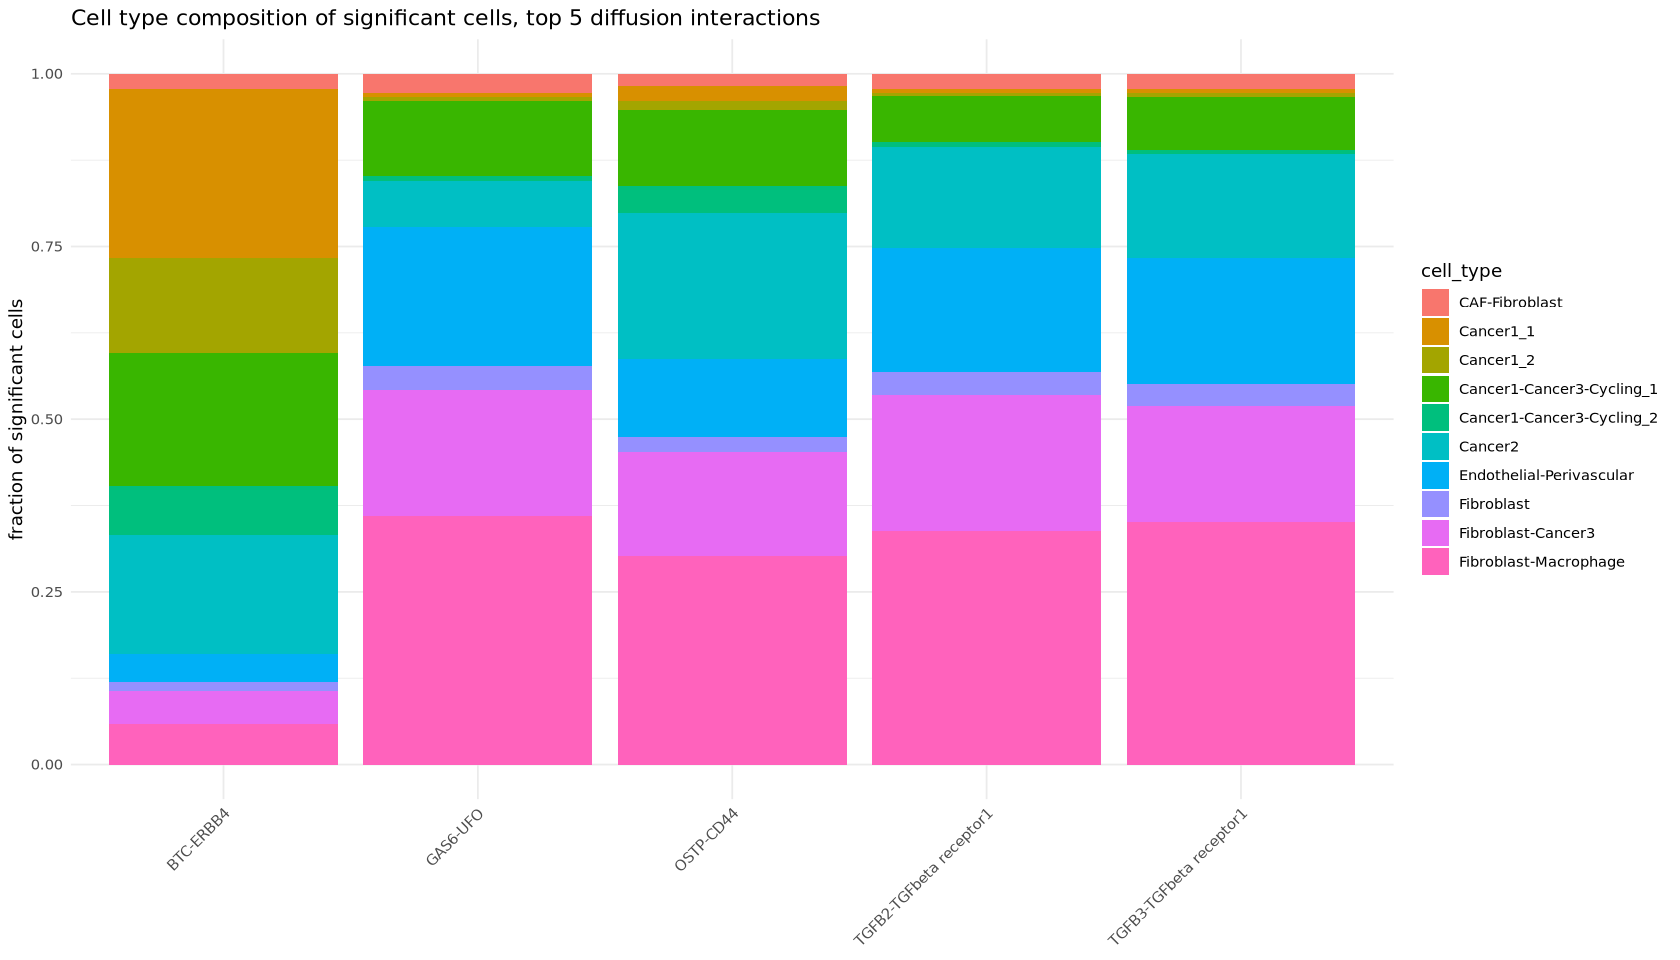

In [33]:
# fraction of each cell type among cells significant for the top 5 diffusion interactions,
# vs. their overall abundance.
# res.list[[SIGNIF_USE]] is a named list keyed by interaction id, each element the
# character vector of cell barcodes significant for that interaction (see analysis.r:inferSignif).
top5 <- names(top_diff)[seq_len(min(5, length(top_diff)))]
signif_res <- cs@lrscore[["diffusion-Raw_smooth"]]@res.list[[SIGNIF_USE]]

enrich_df <- do.call(rbind, lapply(top5, function(id) {
  sig_cells <- intersect(signif_res[[id]], names(cs@clusters))
  tab <- table(cs@clusters[sig_cells])
  data.frame(intr = top_diff[[id]], cell_type = names(tab), n = as.numeric(tab))
}))

ggplot(enrich_df, aes(x = intr, y = n, fill = cell_type)) +
  geom_bar(stat = "identity", position = "fill") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(y = "fraction of significant cells", x = NULL,
       title = "Cell type composition of significant cells, top 5 diffusion interactions")

## 4. Deep dive: top diffusion interaction

In [25]:
options(repr.plot.width = 14, repr.plot.height = 8)

Top diffusion interaction: TGFB3-TGFbeta receptor1 


Now plotting for interactions: 
TGFB3-TGFbeta receptor1, 
Finished!



$`TGFB3-TGFbeta receptor1`


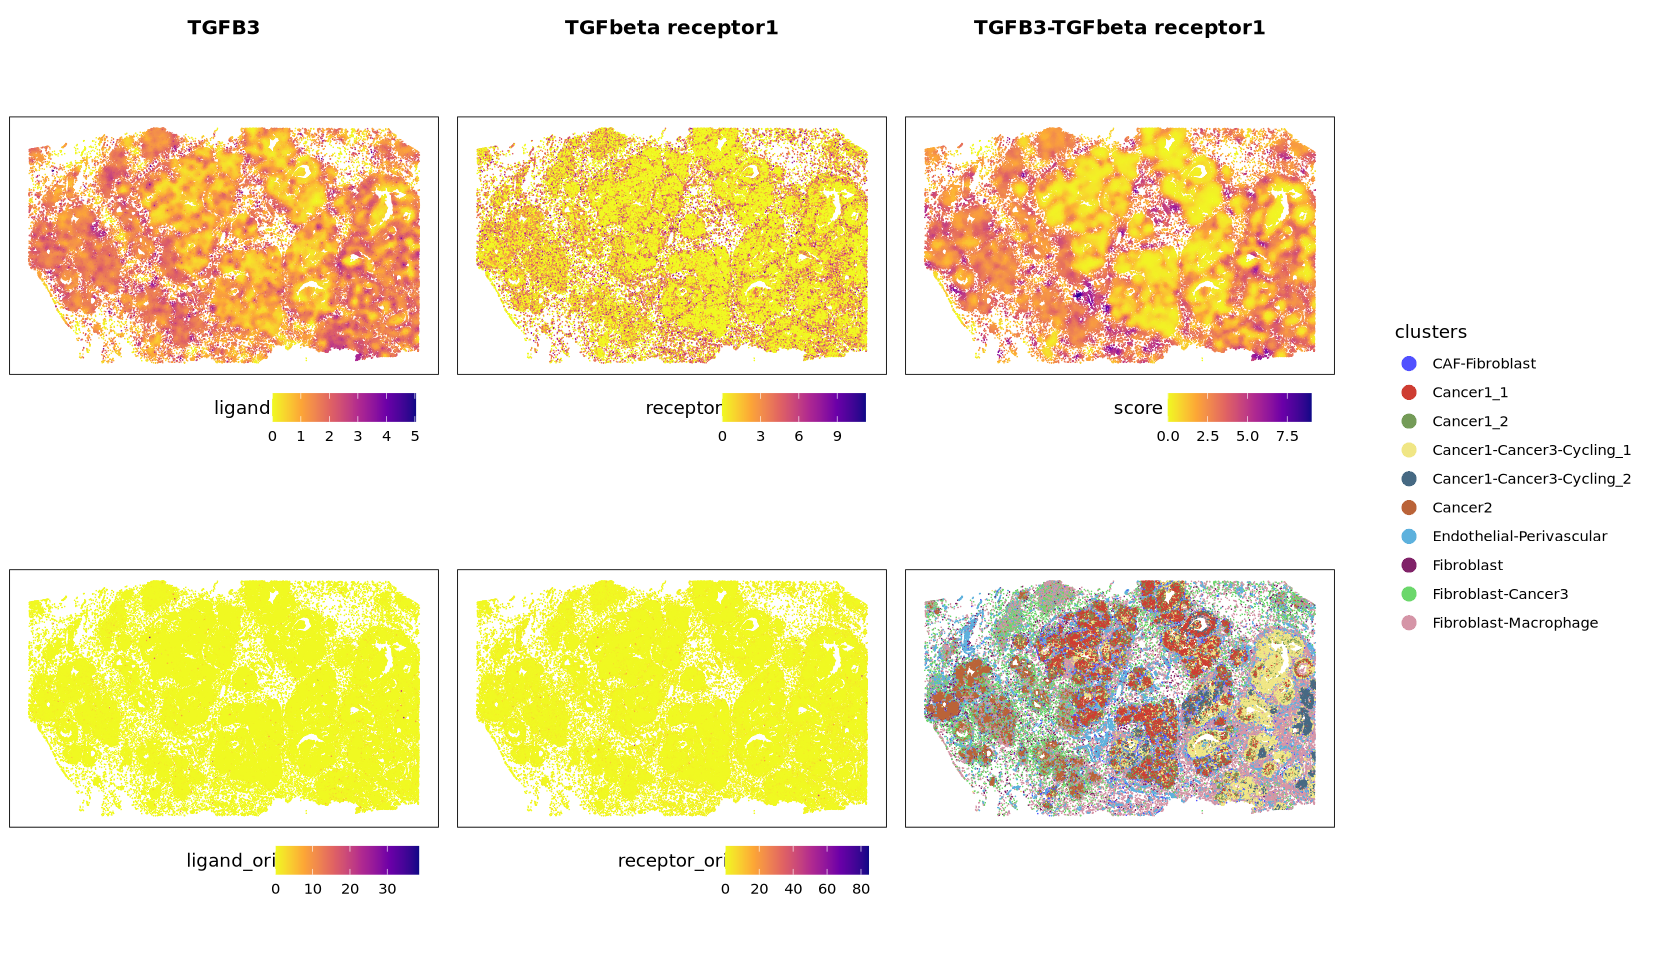

In [26]:
intr.use <- names(top_diff)[1]
cat("Top diffusion interaction:", top_diff[1], "\n")
options(repr.plot.width = 14, repr.plot.height = 8)
plotSignif(cs, intr = intr.use, slot.use = "diffusion-Raw_smooth",
           signif.use = SIGNIF_USE, return.plot = TRUE, edge = FALSE, pt.size = 0.2, raster = FALSE)

Top diffusion interaction: TGFB3-TGFbeta receptor1 


Edge plots already exist. Skip plotting edges.

Now plotting for interactions: 
TGFB3-TGFbeta receptor1, 
Finished!



$`TGFB3-TGFbeta receptor1`


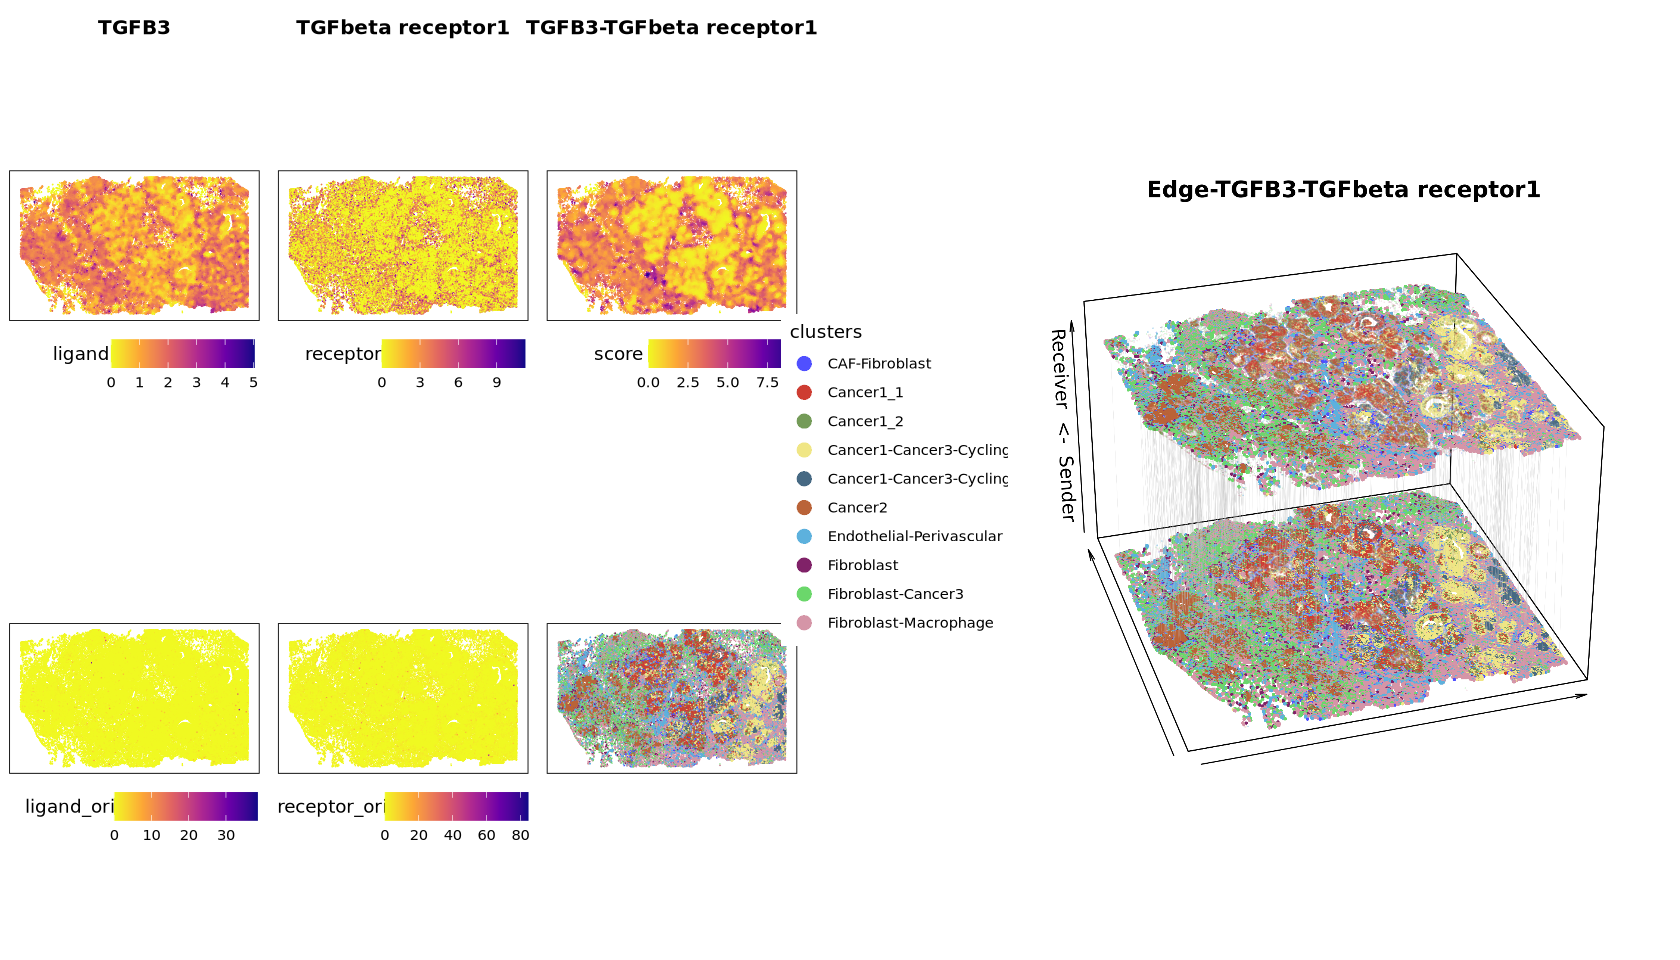

In [27]:
intr.use <- names(top_diff)[1]
cat("Top diffusion interaction:", top_diff[1], "\n")
options(repr.plot.width = 14, repr.plot.height = 8)
plotSignif(cs, intr = intr.use, slot.use = "diffusion-Raw_smooth",
           signif.use = SIGNIF_USE, return.plot = TRUE, edge = TRUE, pt.size = 0.2, raster = FALSE)

## 5. Deep dive: top contact interaction

Top contact interaction: JAG1-NOTC3 


Now plotting for interactions: 
JAG1-NOTC3, 
Finished!



$`JAG1-NOTC3`


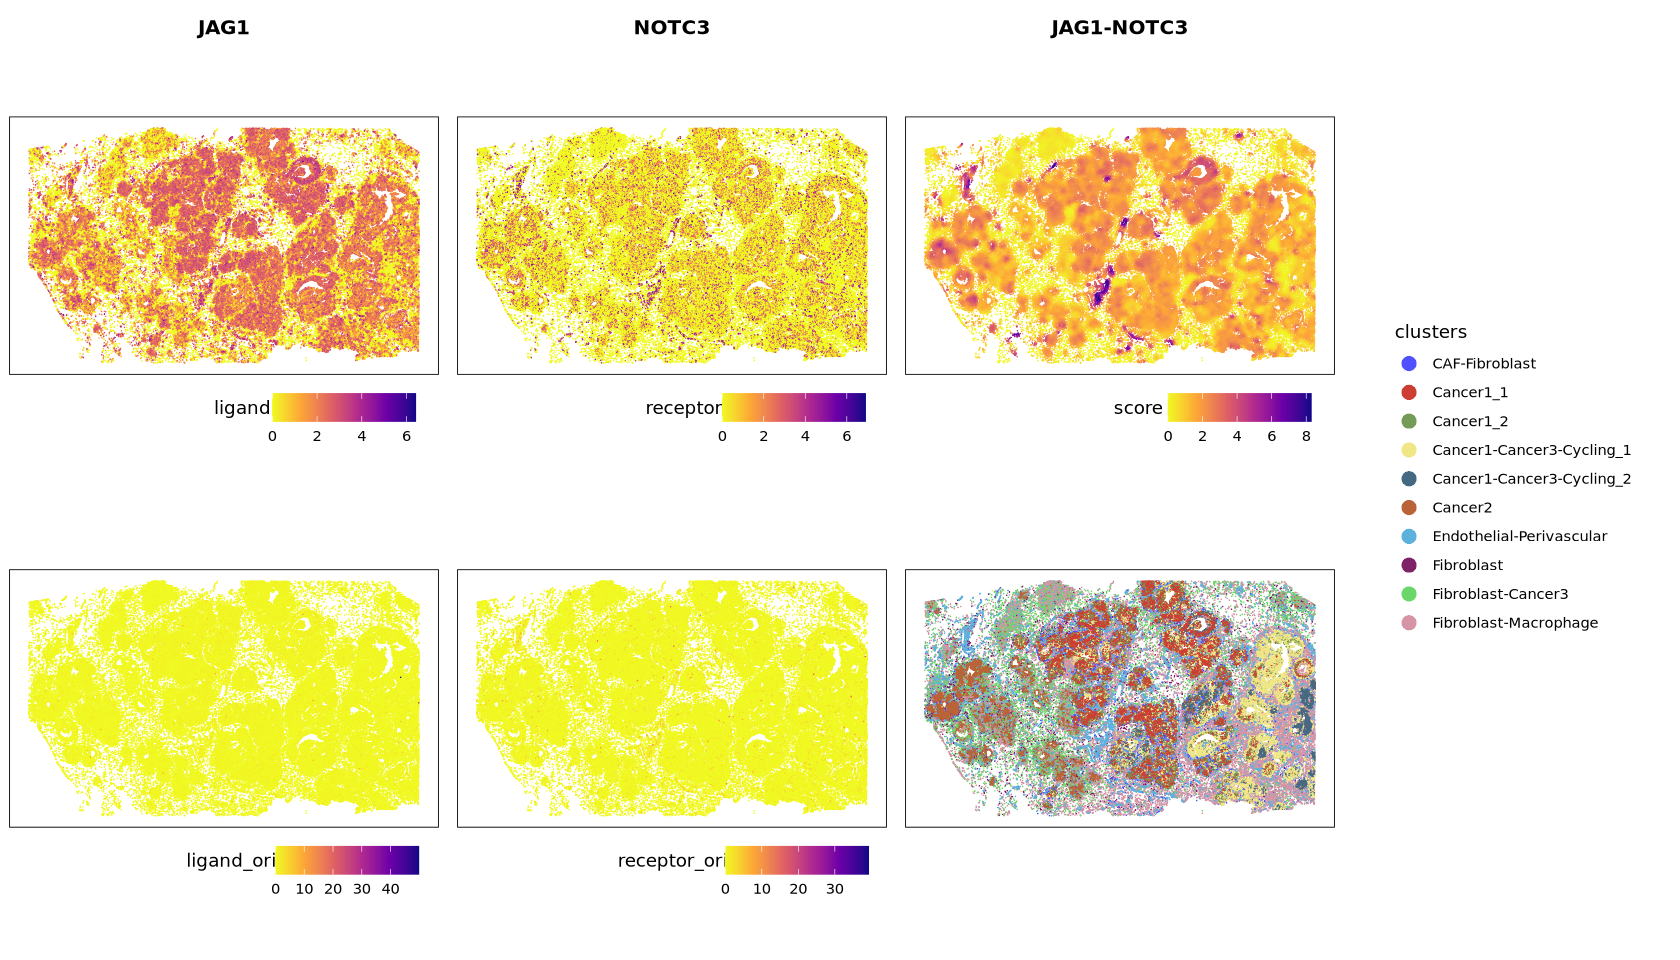

In [28]:
intr.use.cont <- names(top_cont)[1]
cat("Top contact interaction:", top_cont[1], "\n")
plotSignif(cs, intr = intr.use.cont, slot.use = "contact-Raw_smooth",
           signif.use = SIGNIF_USE, return.plot = TRUE, edge = FALSE, pt.size = 0.2, raster=FALSE)

Top contact interaction: JAG1-NOTC3 


Edge plots exist but not for all interactions. Replotting edges.

Warning message:
“no DISPLAY variable so Tk is not available”
Now plotting for interactions: 
JAG1-NOTC3, 
Finished!



$`JAG1-NOTC3`


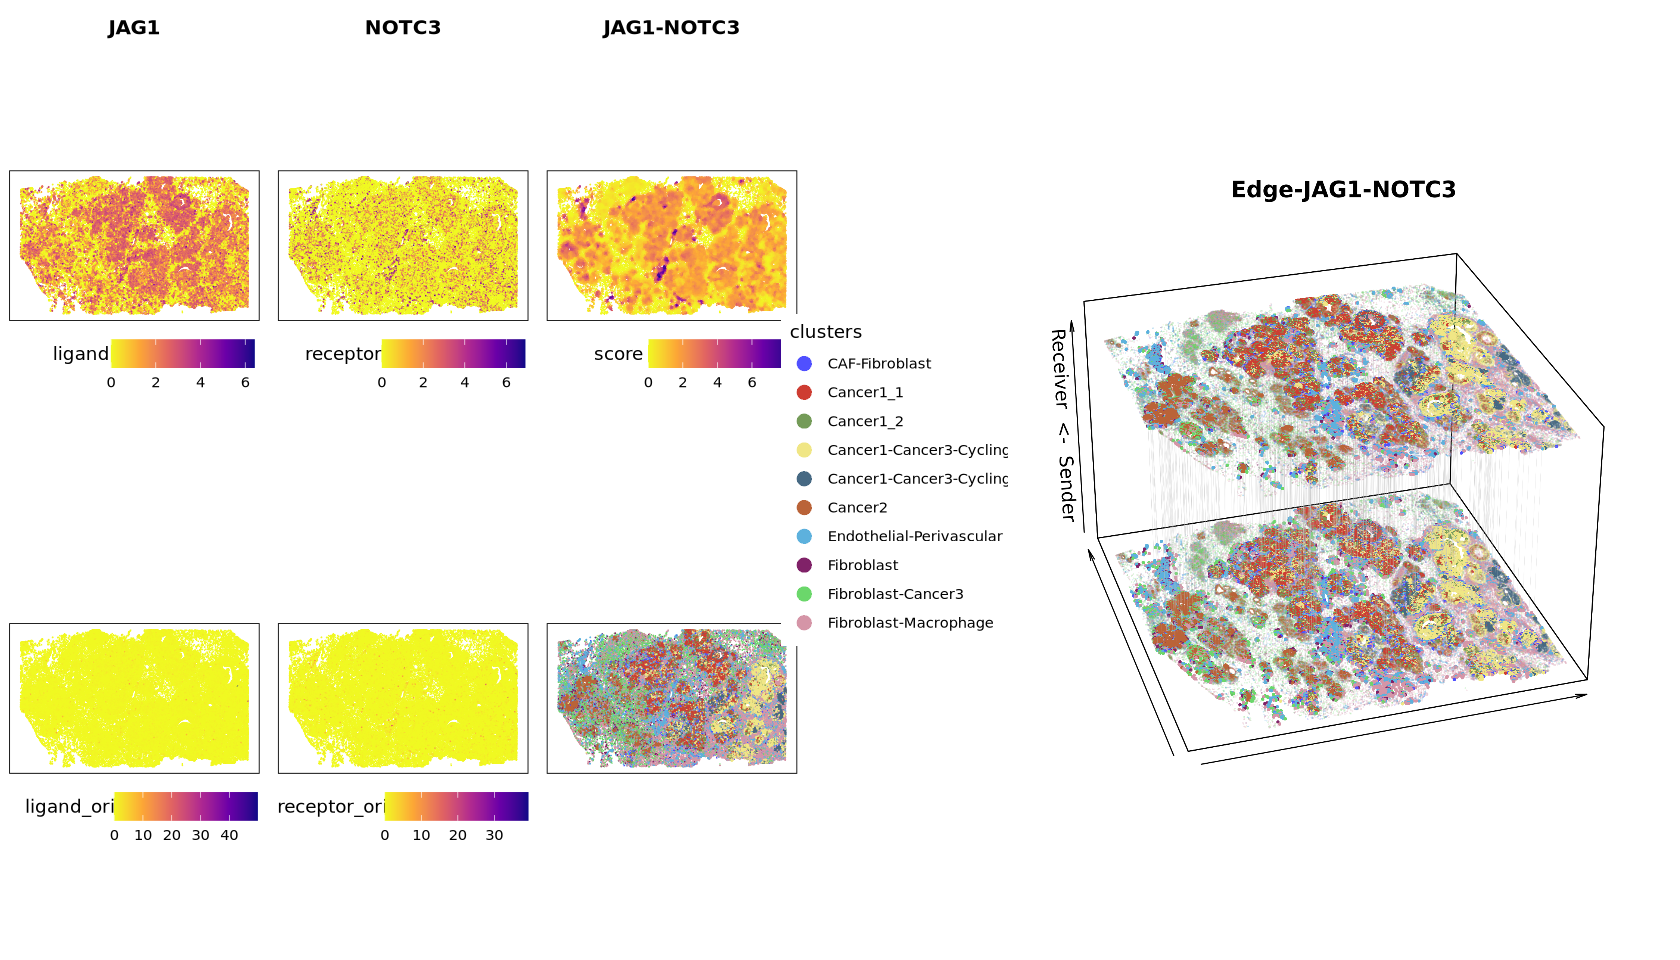

In [29]:
intr.use.cont <- names(top_cont)[1]
cat("Top contact interaction:", top_cont[1], "\n")
plotSignif(cs, intr = intr.use.cont, slot.use = "contact-Raw_smooth",
           signif.use = SIGNIF_USE, return.plot = TRUE, edge = TRUE, pt.size = 0.2, raster=FALSE)